In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from omegaconf import OmegaConf, DictConfig


def collect_sweep_results(multirun_dir):
    rows = []
    base_path = Path(multirun_dir)
    
    if not base_path.exists():
        print(f"Error: Directory not found: {base_path}")
        return pd.DataFrame()

    config_files = list(base_path.rglob(".hydra/config.yaml"))
    if not config_files:
        # .hydraが見つからない場合、直下のconfig.yamlを探す
        config_files = list(base_path.rglob("config.yaml"))

    print(f"Found {len(config_files)} job directories. Starting data collection...")

    for config_path in config_files:
        job_dir = config_path.parent.parent if ".hydra" in str(config_path) else config_path.parent
        data_path = job_dir / "data" / "classification_results.npz"
        
        if data_path.exists():
            try:
                cfg = OmegaConf.load(config_path)
                data = np.load(data_path)
                
                # --- 1. 全パラメータをフラットな辞書に変換 ---
                # task配下にある設定もトップレベルに引き上げる
                flat_cfg = {}
                def flatten_config(cfg_item, prefix=''):
                    for k, v in cfg_item.items():
                        # キー名を階層構造にする (例: task.exc_syn_weight)
                        full_key = f"{prefix}{k}"
                        if isinstance(v, (dict, DictConfig)):
                            # ★修正: full_key にセパレータを追加して再帰に渡す
                            flatten_config(v, prefix=f"{full_key}.")
                        else:
                            flat_cfg[full_key] = v
                
                flatten_config(cfg)

                # --- 2. 精度計算 ---
                conf_mat = data['confusion_matrix']
                total = np.sum(conf_mat)
                acc = np.trace(conf_mat) / total if total > 0 else np.nan
                
                # --- 3. 行データの作成 ---
                row = {**flat_cfg} # 全パラメータを投入
                row.update({
                    "accuracy": acc,
                    "job_id": job_dir.name
                })
                rows.append(row)

            except Exception as e:
                print(f"Skipping {config_path} due to error: {e}")

    df = pd.DataFrame(rows)
    
    if not df.empty:
        # --- 4. スイープされた（値が変化した）列を特定 ---
        # 全ての行で値が同じ列（固定パラメータ）を除外して表示用に整理
        varying_params = [col for col in df.columns if df[col].nunique() > 1]
        print(f"Detected sweep parameters: {varying_params}")
        
        # ソート（存在する列で動的に行う）
        sort_cols = [c for c in varying_params if c in df.columns]
        df = df.sort_values(sort_cols).reset_index(drop=True)
        
        print(f"Successfully collected {len(df)} results.")
    
    return df

#df = collect_sweep_results("../multirun/2026-04-18/15-34-10") # task.exc_syn_weight
#df = collect_sweep_results("../multirun/2026-04-20/10-40-54")  # task.jitter_std
df = collect_sweep_results("../multirun/2026-04-20/19-14-18")  # task.jitter_std

Found 220 job directories. Starting data collection...
Detected sweep parameters: ['task.jitter_std', 'seed', 'accuracy', 'job_id']
Successfully collected 220 results.


--- Data Summary ---
         accuracy  task.jitter_std
count  220.000000       220.000000
mean     0.690818        25.000000
std      0.147147        15.847446
min      0.400000         0.000000
25%      0.600000        10.000000
50%      0.680000        25.000000
75%      0.760000        40.000000
max      1.000000        50.000000
Unique accuracy values: [1.   0.68 0.84 0.86 0.78 0.9  0.88 0.72 0.82 0.8  0.74 0.76 0.62 0.66
 0.7  0.58 0.56 0.54 0.6  0.52 0.64 0.5  0.42 0.44 0.46 0.48 0.4 ]
Plotting 1D Sweep Lineplot: task.jitter_std


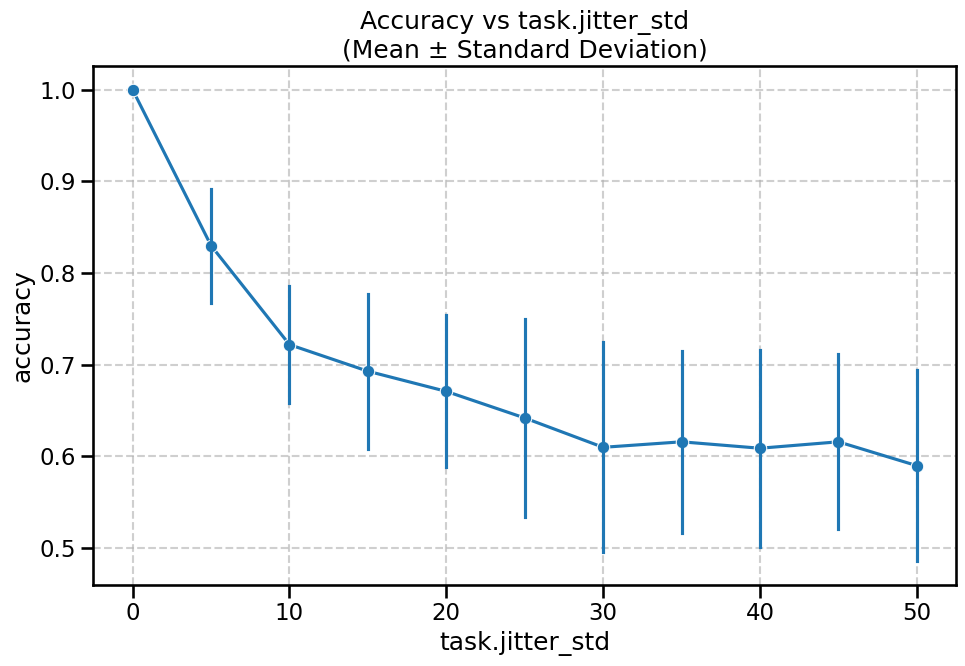

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_results(df):
    # 1. データが入っているかチェック
    if df.empty:
        print("Error: DataFrame is empty. Please check your data collection path.")
        return

    # 2. 対象パラメータの存在確認（デバッグ用）
    target_params = ["task.exc_syn_weight", "task.jitter_std"]
    available_params = [p for p in target_params if p in df.columns]
    
    if not available_params:
        print(f"Error: Target parameters {target_params} not found in DataFrame.")
        print(f"Available columns are: {list(df.columns)}")
        return

    # 3. スイープ（2種類以上の値がある）されているパラメータを特定
    sweep_params = [p for p in available_params if df[p].nunique() > 1]
    # 関数の最初の方に追加
    print("--- Data Summary ---")
    print(df[['accuracy'] + sweep_params].describe()) 
    print("Unique accuracy values:", df['accuracy'].unique())
    
    plt.figure(figsize=(10, 7))
    sns.set_context("talk") # 論文や発表で見やすい文字サイズに設定

    # --- パターンA: 2変数スイープ (ヒートマップ) ---
    if len(sweep_params) >= 2:
        print(f"Plotting 2D Sweep Heatmap: {sweep_params[0]} vs {sweep_params[1]}")
        # シード間の平均精度を算出
        pivot_df = df.groupby([sweep_params[0], sweep_params[1]])['accuracy'].mean().unstack()
        
        sns.heatmap(pivot_df, annot=True, cmap="viridis", fmt=".3f",
                    cbar_kws={'label': 'Mean Accuracy'})
        plt.gca().invert_yaxis()  # 平均が下から上に大きくなるように調整
        plt.title(f"Accuracy Heatmap\n({sweep_params[0]} vs {sweep_params[1]})")

    # --- パターンB: 1変数スイープ (折れ線グラフ) ---
    elif len(sweep_params) == 1:
        param = sweep_params[0]
        print(f"Plotting 1D Sweep Lineplot: {param}")
        # エラーバー（標準偏差 sd）を表示
        sns.lineplot(data=df, x=param, y="accuracy", marker='o', 
                     errorbar='sd', err_style="bars")
        plt.title(f"Accuracy vs {param}\n(Mean ± Standard Deviation)")
        plt.grid(True, linestyle='--', alpha=0.6)

    # --- パターンC: 全て固定値、またはシードのみの違い (箱ひげ図) ---
    else:
        print("Plotting Distribution for Fixed Parameters")
        sns.boxplot(data=df, y="accuracy", color="skyblue")
        sns.stripplot(data=df, y="accuracy", color="black", alpha=0.5)
        plt.title("Accuracy Distribution")

    plt.tight_layout()
    plt.savefig('position-accuracy.png')
    plt.show()

# 使い方
plot_results(df)